Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




CHECKING TENSORFLOW
TensorFlow Version: 2.21.0 

LOADING MNIST DATASET
Original Training Images: 60000 
Original Testing Images: 10000 
Training Images Used: 5000 
Testing Images Used: 1000 

CONVERTING TRAINING IMAGES TO 5x5
Training Image Dimensions: 5000 x 5 x 5 

CONVERTING TESTING IMAGES TO 5x5
Testing Image Dimensions: 1000 x 5 x 5 

Displaying 5x5 sample images...

FLATTENING 5x5 IMAGES
Training Matrix: 5000 x 25 
Testing Matrix: 1000 x 25 

ENCODING CLASS LABELS
Number of Classes: 10

BUILDING NEURAL NETWORK

MODEL SUMMARY
Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                     │ (None, 64)               │         1,664 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │

agg_record_47a60320ff6 
                     2

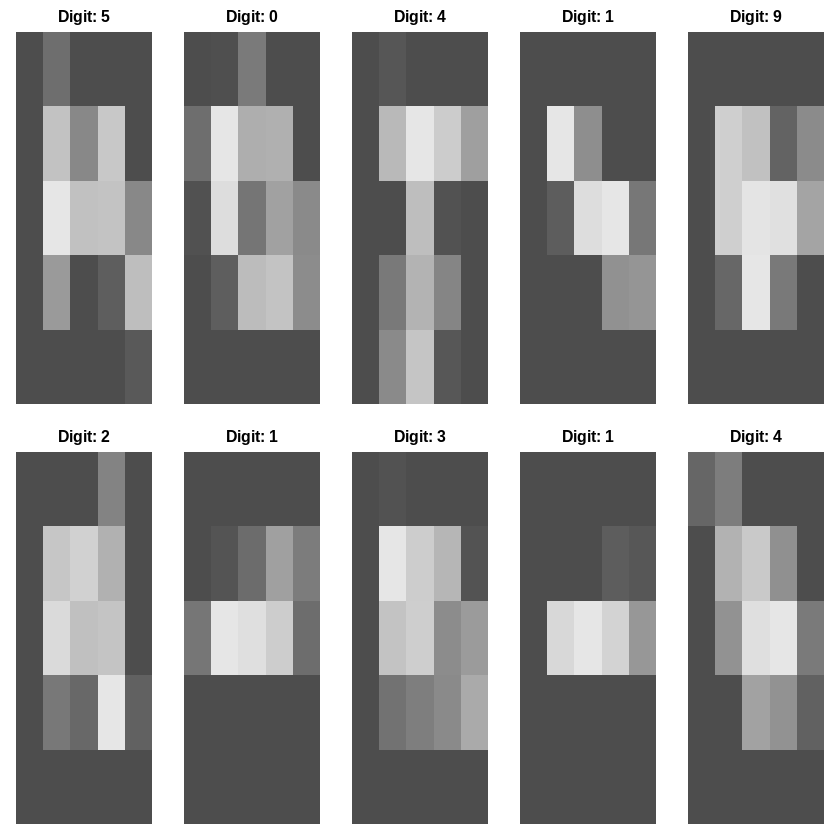


CREATING LOSS GRAPH


agg_record_47a60320ff6 
                     2

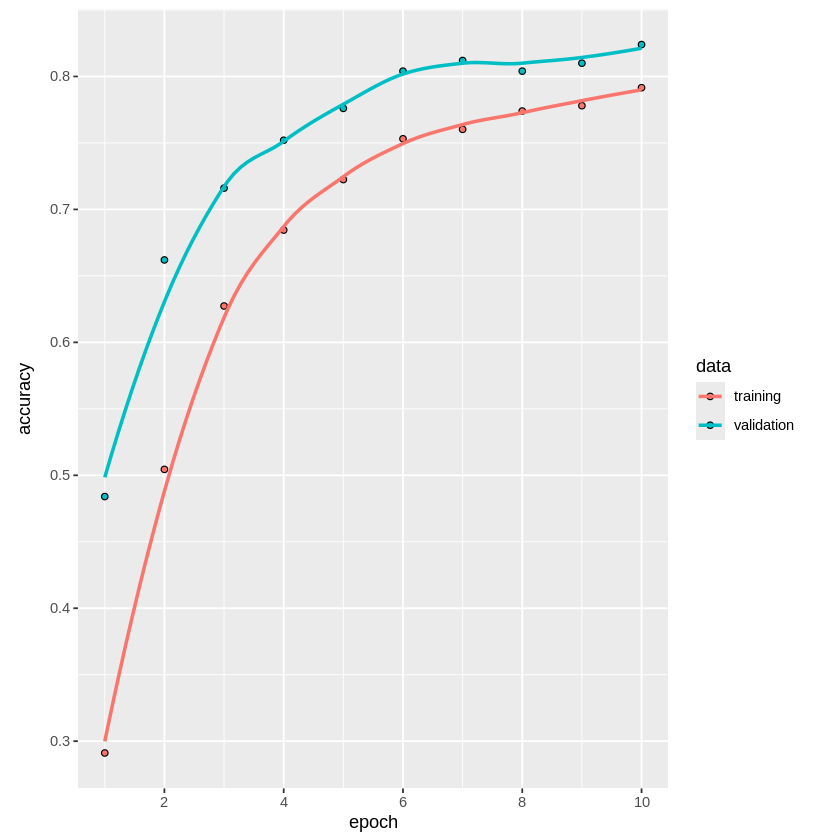


MODEL TESTING
Test Loss: 0.6712 
Test Accuracy: 78.5 %

GENERATING PREDICTIONS

First 20 predictions:
   Image_ID Actual_Digit Predicted_Digit Correct
1         1            7               7    TRUE
2         2            2               2    TRUE
3         3            1               1    TRUE
4         4            0               0    TRUE
5         5            4               4    TRUE
6         6            1               1    TRUE
7         7            4               4    TRUE
8         8            9               9    TRUE
9         9            5               5    TRUE
10       10            9               9    TRUE
11       11            0               0    TRUE
12       12            6               6    TRUE
13       13            9               9    TRUE
14       14            0               0    TRUE
15       15            1               1    TRUE
16       16            5               3   FALSE
17       17            9               9    TRUE
18       18    

agg_record_47a60320ff6 
                     2

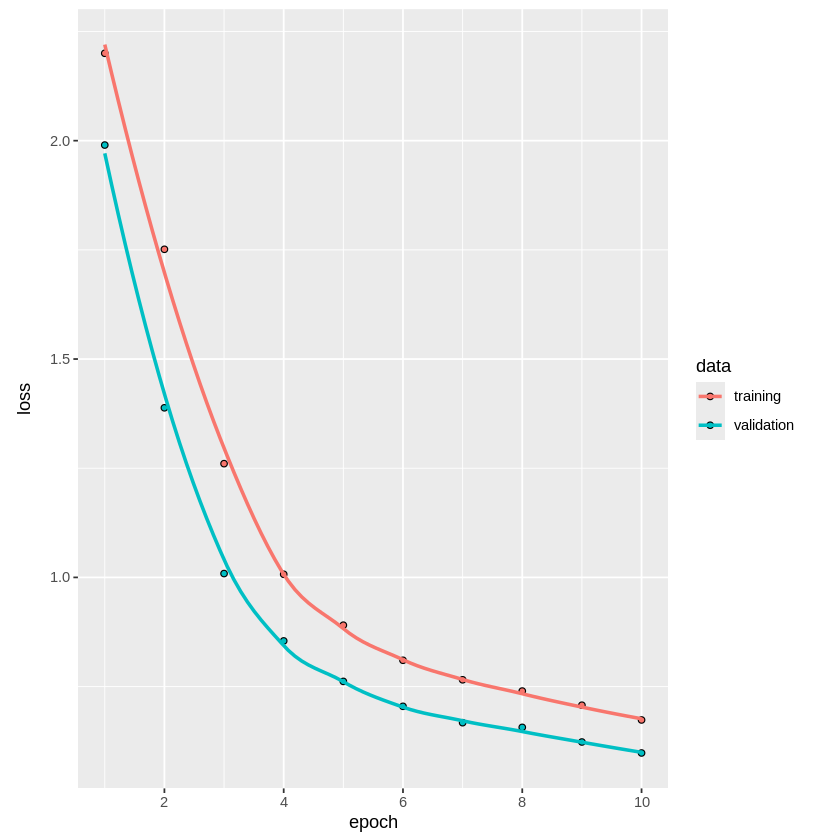


CLASS-WISE ACCURACY
  Digit Accuracy_Percentage
0     0               95.29
1     1               95.24
2     2               75.86
3     3               71.03
4     4               76.36
5     5               60.92
6     6               85.06
7     7               84.85
8     8               52.81
9     9               82.98


agg_record_47a60320ff6 
                     2

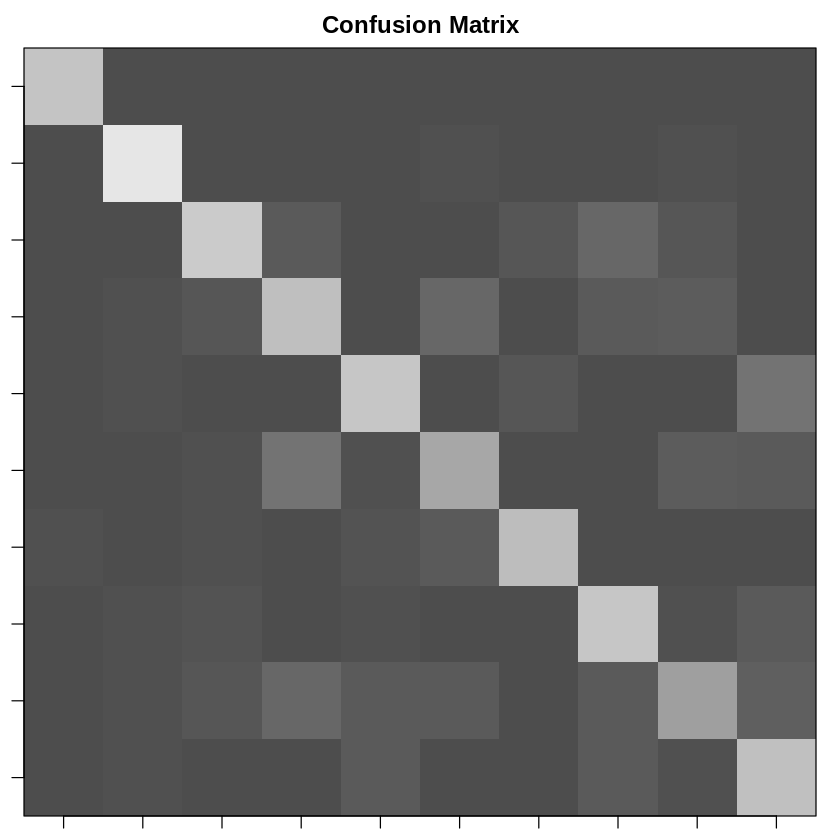


OVERALL PERFORMANCE
Overall Accuracy: 78.5 %

Displaying sample 5x5 test images...


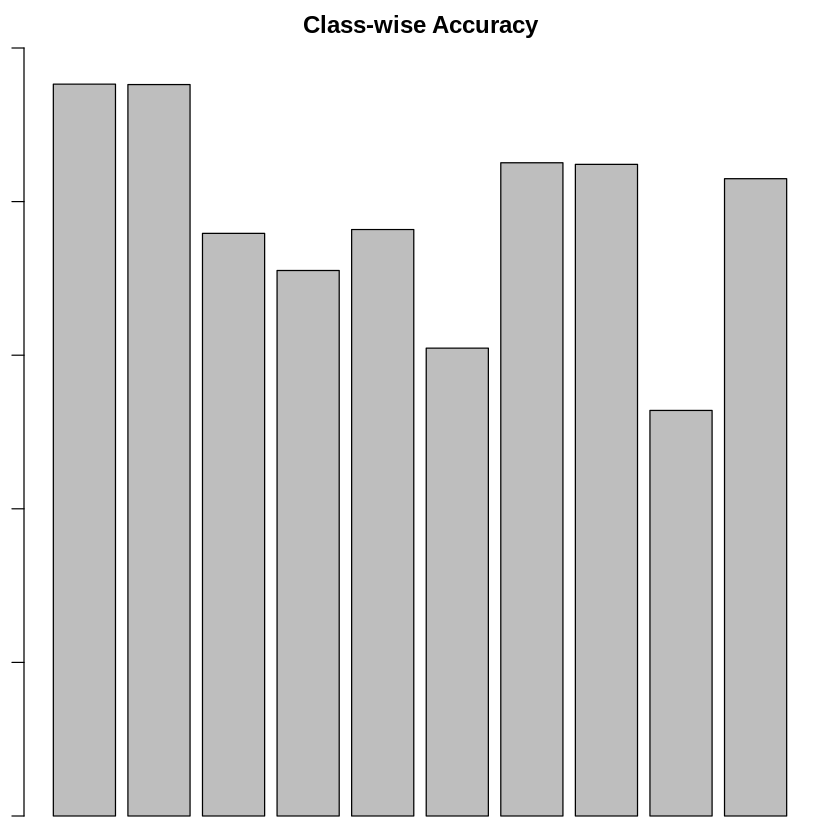

agg_record_47a60320ff6 
                     2


Saving trained model...


       LAB PROBLEM 4 COMPLETED SUCCESSFULLY
Dataset                : MNIST
Training Images        : 5000 
Testing Images         : 1000 
Original Image Size    : 28 x 28
Preprocessed Size      : 5 x 5
Input Features         : 25
Number of Classes      : 10
Model                  : Neural Network
Test Loss              : 0.6712 
Test Accuracy          : 78.5 %

Generated Output Files:
1. training_history.rds
2. accuracy_graph.png
3. loss_graph.png
4. confusion_matrix.png
5. confusion_matrix.csv
6. prediction_results.csv
7. class_wise_accuracy.csv
8. class_accuracy_graph.png
9. sample_predictions.png
10. digit_classification_5x5.keras
11. results_summary.csv
12. dataset_information.csv

Project execution completed.


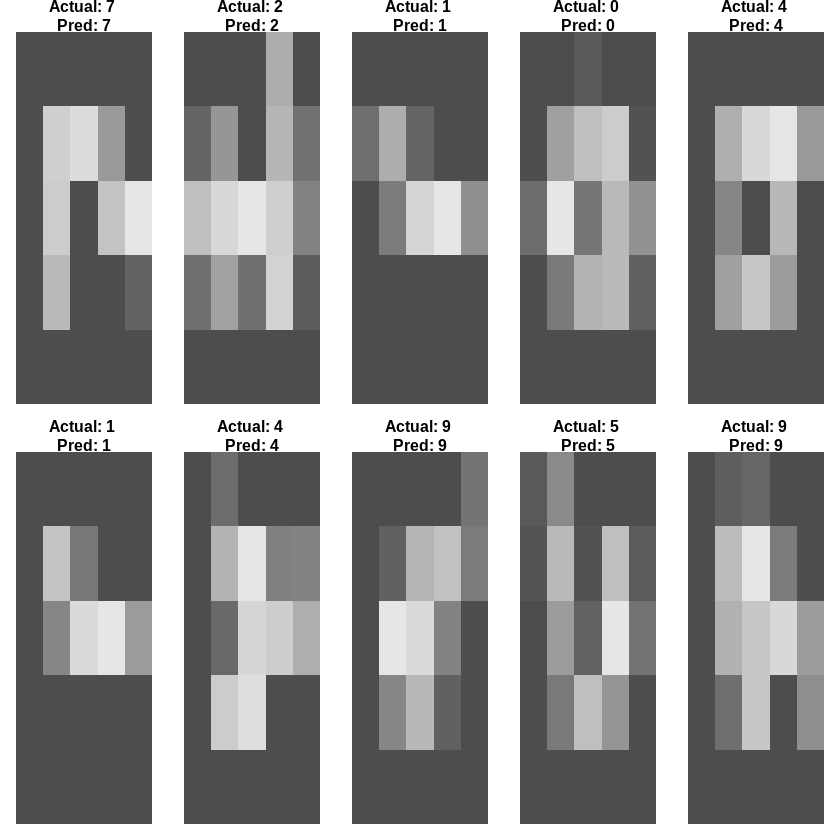

In [4]:
# ============================================================
# LAB PROBLEM 4
# R PROJECT IMPLEMENTATION AND VERSION CONTROL USING GITHUB
# ============================================================
#
# PROJECT:
# Digit Classification Using R with 5x5 Image Preprocessing
#
# DATASET:
# MNIST
#
# OBJECTIVE:
# To implement an image classification project in R by
# preprocessing MNIST images into 5x5 images, training a
# neural network, evaluating the model, generating predictions,
# creating a confusion matrix and saving project outputs.
#
# ============================================================


# ============================================================
# 1. INSTALL AND LOAD REQUIRED PACKAGES
# ============================================================

install.packages(c(
  "keras3",
  "tensorflow"
))

library(keras3)
library(tensorflow)


# ============================================================
# 2. CHECK TENSORFLOW
# ============================================================

cat("\n============================================\n")
cat("CHECKING TENSORFLOW\n")
cat("============================================\n")

tf <- reticulate::import("tensorflow")

cat(
  "TensorFlow Version:",
  tf$`__version__`,
  "\n"
)


# ============================================================
# 3. LOAD MNIST DATASET
# ============================================================

cat("\n============================================\n")
cat("LOADING MNIST DATASET\n")
cat("============================================\n")

mnist <- dataset_mnist()

x_train_original <- mnist$train$x
y_train_original <- mnist$train$y

x_test_original <- mnist$test$x
y_test_original <- mnist$test$y


cat(
  "Original Training Images:",
  dim(x_train_original)[1],
  "\n"
)

cat(
  "Original Testing Images:",
  dim(x_test_original)[1],
  "\n"
)


# ============================================================
# 4. USE A SMALL SUBSET
# ============================================================
#
# To make the project fast in Google Colab:
#
# Training = 5,000 images
# Testing  = 1,000 images
#
# ============================================================

TRAIN_SIZE <- 5000
TEST_SIZE <- 1000


x_train_original <-
  x_train_original[1:TRAIN_SIZE, , ]

y_train <-
  y_train_original[1:TRAIN_SIZE]

x_test_original <-
  x_test_original[1:TEST_SIZE, , ]

y_test <-
  y_test_original[1:TEST_SIZE]


cat(
  "Training Images Used:",
  TRAIN_SIZE,
  "\n"
)

cat(
  "Testing Images Used:",
  TEST_SIZE,
  "\n"
)


# ============================================================
# 5. FUNCTION TO RESIZE IMAGE TO 5x5
# ============================================================

resize_to_5x5 <- function(images) {

  n <- dim(images)[1]

  resized <- array(
    0,
    dim = c(n, 5, 5)
  )

  for(i in 1:n) {

    img <- images[i,,]

    # Normalize original image
    img <- img / 255

    # Convert image to matrix
    img <- matrix(
      img,
      nrow = 28,
      ncol = 28
    )

    # Simple 5x5 downsampling
    #
    # Each 5x5 pixel represents an average
    # of the corresponding region of the
    # original 28x28 image.

    for(r in 1:5) {

      for(c in 1:5) {

        row_start <-
          floor((r - 1) * 28 / 5) + 1

        row_end <-
          floor(r * 28 / 5)

        col_start <-
          floor((c - 1) * 28 / 5) + 1

        col_end <-
          floor(c * 28 / 5)

        block <-
          img[
            row_start:row_end,
            col_start:col_end
          ]

        resized[i,r,c] <-
          mean(block)
      }
    }
  }

  return(resized)
}


# ============================================================
# 6. CONVERT TRAINING IMAGES TO 5x5
# ============================================================

cat("\n============================================\n")
cat("CONVERTING TRAINING IMAGES TO 5x5\n")
cat("============================================\n")

x_train_5x5 <-
  resize_to_5x5(
    x_train_original
  )

cat(
  "Training Image Dimensions:",
  paste(
    dim(x_train_5x5),
    collapse = " x "
  ),
  "\n"
)


# ============================================================
# 7. CONVERT TESTING IMAGES TO 5x5
# ============================================================

cat("\n============================================\n")
cat("CONVERTING TESTING IMAGES TO 5x5\n")
cat("============================================\n")

x_test_5x5 <-
  resize_to_5x5(
    x_test_original
  )

cat(
  "Testing Image Dimensions:",
  paste(
    dim(x_test_5x5),
    collapse = " x "
  ),
  "\n"
)


# ============================================================
# 8. DISPLAY 5x5 SAMPLE IMAGES
# ============================================================

cat("\nDisplaying 5x5 sample images...\n")


par(
  mfrow = c(2, 5),
  mar = c(1, 1, 2, 1)
)


for(i in 1:10) {

  image(
    x = 1:5,
    y = 1:5,
    z = x_train_5x5[i,,],
    col = gray.colors(256),
    axes = FALSE,
    xlab = "",
    ylab = ""
  )

  title(
    paste(
      "Digit:",
      y_train[i]
    )
  )
}


par(
  mfrow = c(1, 1)
)


# ============================================================
# 9. FLATTEN 5x5 IMAGES
# ============================================================
#
# 5 x 5 = 25 input features
#
# ============================================================

cat("\n============================================\n")
cat("FLATTENING 5x5 IMAGES\n")
cat("============================================\n")


x_train <- array(
  x_train_5x5,
  dim = c(
    TRAIN_SIZE,
    25
  )
)


x_test <- array(
  x_test_5x5,
  dim = c(
    TEST_SIZE,
    25
  )
)


cat(
  "Training Matrix:",
  paste(
    dim(x_train),
    collapse = " x "
  ),
  "\n"
)

cat(
  "Testing Matrix:",
  paste(
    dim(x_test),
    collapse = " x "
  ),
  "\n"
)


# ============================================================
# 10. ONE-HOT ENCODING
# ============================================================

cat("\n============================================\n")
cat("ENCODING CLASS LABELS\n")
cat("============================================\n")


y_train_encoded <-
  to_categorical(
    y_train,
    num_classes = 10
  )


y_test_encoded <-
  to_categorical(
    y_test,
    num_classes = 10
  )


cat(
  "Number of Classes: 10\n"
)


# ============================================================
# 11. BUILD NEURAL NETWORK
# ============================================================

cat("\n============================================\n")
cat("BUILDING NEURAL NETWORK\n")
cat("============================================\n")


model <- keras_model_sequential()


model |>
  layer_dense(
    units = 64,
    activation = "relu",
    input_shape = 25
  ) |>

  layer_dropout(
    rate = 0.20
  ) |>

  layer_dense(
    units = 32,
    activation = "relu"
  ) |>

  layer_dense(
    units = 10,
    activation = "softmax"
  )


# ============================================================
# 12. DISPLAY MODEL SUMMARY
# ============================================================

cat("\n============================================\n")
cat("MODEL SUMMARY\n")
cat("============================================\n")

summary(model)


# ============================================================
# 13. COMPILE MODEL
# ============================================================

cat("\n============================================\n")
cat("COMPILING MODEL\n")
cat("============================================\n")


model |>
  compile(
    optimizer = optimizer_adam(
      learning_rate = 0.001
    ),

    loss = "categorical_crossentropy",

    metrics = c(
      "accuracy"
    )
  )


cat(
  "Model compiled successfully.\n"
)


# ============================================================
# 14. TRAIN MODEL
# ============================================================

cat("\n============================================\n")
cat("TRAINING MODEL\n")
cat("============================================\n")


history <- model |>
  fit(

    x_train,

    y_train_encoded,

    epochs = 10,

    batch_size = 64,

    validation_split = 0.10,

    verbose = 1
  )


# ============================================================
# 15. SAVE TRAINING HISTORY
# ============================================================

saveRDS(
  history,
  "training_history.rds"
)


# ============================================================
# 16. PLOT TRAINING AND VALIDATION ACCURACY
# ============================================================

cat("\n============================================\n")
cat("CREATING ACCURACY GRAPH\n")
cat("============================================\n")


png(
  "accuracy_graph.png",
  width = 900,
  height = 600
)


plot(
  history,
  metrics = "accuracy",
  main = "Training and Validation Accuracy"
)


dev.off()


# Display graph
plot(
  history,
  metrics = "accuracy",
  main = "Training and Validation Accuracy"
)


# ============================================================
# 17. PLOT TRAINING AND VALIDATION LOSS
# ============================================================

cat("\n============================================\n")
cat("CREATING LOSS GRAPH\n")
cat("============================================\n")


png(
  "loss_graph.png",
  width = 900,
  height = 600
)


plot(
  history,
  metrics = "loss",
  main = "Training and Validation Loss"
)


dev.off()


# Display graph
plot(
  history,
  metrics = "loss",
  main = "Training and Validation Loss"
)


# ============================================================
# 18. EVALUATE MODEL
# ============================================================

cat("\n============================================\n")
cat("MODEL TESTING\n")
cat("============================================\n")


results <- model |>
  evaluate(
    x_test,
    y_test_encoded,
    verbose = 1
  )


test_loss <-
  as.numeric(
    results["loss"]
  )


test_accuracy <-
  as.numeric(
    results["accuracy"]
  )


cat(
  "Test Loss:",
  round(
    test_loss,
    4
  ),
  "\n"
)


cat(
  "Test Accuracy:",
  round(
    test_accuracy * 100,
    2
  ),
  "%\n"
)


# ============================================================
# 19. PREDICTIONS
# ============================================================

cat("\n============================================\n")
cat("GENERATING PREDICTIONS\n")
cat("============================================\n")


predictions <- model |>
  predict(
    x_test,
    verbose = 1
  )


# Convert probabilities to predicted class
predicted_classes <-
  apply(
    predictions,
    1,
    which.max
  ) - 1


# Actual classes
actual_classes <-
  y_test


# ============================================================
# 20. CREATE PREDICTION TABLE
# ============================================================

prediction_table <- data.frame(

  Image_ID = 1:TEST_SIZE,

  Actual_Digit =
    actual_classes,

  Predicted_Digit =
    predicted_classes

)


prediction_table$Correct <-
  prediction_table$Actual_Digit ==
  prediction_table$Predicted_Digit


cat("\nFirst 20 predictions:\n")

print(
  head(
    prediction_table,
    20
  )
)


# ============================================================
# 21. SAVE PREDICTIONS
# ============================================================

write.csv(
  prediction_table,
  "prediction_results.csv",
  row.names = FALSE
)


# ============================================================
# 22. CONFUSION MATRIX
# ============================================================

cat("\n============================================\n")
cat("CONFUSION MATRIX\n")
cat("============================================\n")


confusion_matrix <-
  table(

    Actual =
      factor(
        actual_classes,
        levels = 0:9
      ),

    Predicted =
      factor(
        predicted_classes,
        levels = 0:9
      )
  )


print(
  confusion_matrix
)


# ============================================================
# 23. SAVE CONFUSION MATRIX
# ============================================================

write.csv(
  as.data.frame(
    confusion_matrix
  ),
  "confusion_matrix.csv",
  row.names = FALSE
)


# ============================================================
# 24. PLOT CONFUSION MATRIX
# ============================================================

png(
  "confusion_matrix.png",
  width = 900,
  height = 800
)


image(
  1:10,
  1:10,
  t(
    confusion_matrix[
      10:1,
      ]
  ),
  axes = FALSE,
  col = gray.colors(100),
  xlab = "Predicted Digit",
  ylab = "Actual Digit",
  main = "Confusion Matrix"
)


axis(
  1,
  at = 1:10,
  labels = 0:9
)


axis(
  2,
  at = 1:10,
  labels = 9:0
)


box()


dev.off()


# Display confusion matrix
image(
  1:10,
  1:10,
  t(
    confusion_matrix[
      10:1,
      ]
  ),
  axes = FALSE,
  col = gray.colors(100),
  xlab = "Predicted Digit",
  ylab = "Actual Digit",
  main = "Confusion Matrix"
)

axis(
  1,
  at = 1:10,
  labels = 0:9
)

axis(
  2,
  at = 1:10,
  labels = 9:0
)

box()


# ============================================================
# 25. CLASS-WISE ACCURACY
# ============================================================

class_accuracy <-
  diag(
    confusion_matrix
  ) /
  rowSums(
    confusion_matrix
  )


class_accuracy_table <- data.frame(

  Digit = 0:9,

  Accuracy_Percentage =
    round(
      class_accuracy * 100,
      2
    )
)


cat("\n============================================\n")
cat("CLASS-WISE ACCURACY\n")
cat("============================================\n")


print(
  class_accuracy_table
)


# ============================================================
# 26. SAVE CLASS-WISE ACCURACY
# ============================================================

write.csv(
  class_accuracy_table,
  "class_wise_accuracy.csv",
  row.names = FALSE
)


# ============================================================
# 27. CLASS-WISE ACCURACY GRAPH
# ============================================================

png(
  "class_accuracy_graph.png",
  width = 900,
  height = 600
)


barplot(
  class_accuracy * 100,

  names.arg = 0:9,

  main =
    "Class-wise Accuracy",

  xlab =
    "Digit",

  ylab =
    "Accuracy (%)",

  ylim =
    c(
      0,
      100
    )
)


dev.off()


# Display
barplot(
  class_accuracy * 100,

  names.arg = 0:9,

  main =
    "Class-wise Accuracy",

  xlab =
    "Digit",

  ylab =
    "Accuracy (%)",

  ylim =
    c(
      0,
      100
    )
)


# ============================================================
# 28. OVERALL ACCURACY
# ============================================================

overall_accuracy <-
  mean(
    actual_classes ==
    predicted_classes
  )


cat("\n============================================\n")
cat("OVERALL PERFORMANCE\n")
cat("============================================\n")


cat(
  "Overall Accuracy:",
  round(
    overall_accuracy * 100,
    2
  ),
  "%\n"
)


# ============================================================
# 29. DISPLAY SAMPLE TEST IMAGES
# ============================================================

cat("\nDisplaying sample 5x5 test images...\n")


par(
  mfrow = c(2, 5),
  mar = c(1, 1, 2, 1)
)


for(i in 1:10) {

  image(

    x = 1:5,

    y = 1:5,

    z = x_test_5x5[i,,],

    col =
      gray.colors(256),

    axes = FALSE,

    xlab = "",

    ylab = ""
  )


  title(
    paste(
      "Actual:",
      actual_classes[i],
      "\nPred:",
      predicted_classes[i]
    )
  )
}


par(
  mfrow = c(1, 1)
)


# ============================================================
# 30. SAVE SAMPLE PREDICTION GRAPH
# ============================================================

png(
  "sample_predictions.png",
  width = 1000,
  height = 700
)


par(
  mfrow = c(2, 5),
  mar = c(1, 1, 2, 1)
)


for(i in 1:10) {

  image(

    x = 1:5,

    y = 1:5,

    z = x_test_5x5[i,,],

    col =
      gray.colors(256),

    axes = FALSE,

    xlab = "",

    ylab = ""
  )


  title(
    paste(
      "Actual:",
      actual_classes[i],
      "\nPred:",
      predicted_classes[i]
    )
  )
}


dev.off()


# ============================================================
# 31. SAVE MODEL
# ============================================================

cat("\nSaving trained model...\n")


save_model(
  model,
  "digit_classification_5x5.keras"
)


# ============================================================
# 32. CREATE RESULTS SUMMARY
# ============================================================

results_summary <- data.frame(

  Dataset =
    "MNIST",

  Training_Images =
    TRAIN_SIZE,

  Testing_Images =
    TEST_SIZE,

  Original_Image_Size =
    "28 x 28",

  Preprocessed_Image_Size =
    "5 x 5",

  Input_Features =
    25,

  Number_of_Classes =
    10,

  Model =
    "Neural Network",

  Test_Loss =
    round(
      test_loss,
      4
    ),

  Test_Accuracy_Percentage =
    round(
      overall_accuracy * 100,
      2
    )
)


# ============================================================
# 33. SAVE RESULTS SUMMARY
# ============================================================

write.csv(
  results_summary,
  "results_summary.csv",
  row.names = FALSE
)


# ============================================================
# 34. SAVE PREPROCESSED DATA
# ============================================================
#
# Saving the complete 5x5 dataset is optional.
# We save only the dimensions and labels here to
# keep the GitHub repository lightweight.
#
# ============================================================

dataset_info <- data.frame(

  Property = c(
    "Dataset",
    "Original Image Size",
    "Preprocessed Image Size",
    "Training Images",
    "Testing Images",
    "Input Features",
    "Number of Classes"
  ),

  Value = c(
    "MNIST",
    "28 x 28",
    "5 x 5",
    TRAIN_SIZE,
    TEST_SIZE,
    25,
    10
  )
)


write.csv(
  dataset_info,
  "dataset_information.csv",
  row.names = FALSE
)


# ============================================================
# 35. FINAL REPORT
# ============================================================

cat("\n\n")
cat("====================================================\n")
cat("       LAB PROBLEM 4 COMPLETED SUCCESSFULLY\n")
cat("====================================================\n")

cat(
  "Dataset                : MNIST\n"
)

cat(
  "Training Images        :",
  TRAIN_SIZE,
  "\n"
)

cat(
  "Testing Images         :",
  TEST_SIZE,
  "\n"
)

cat(
  "Original Image Size    : 28 x 28\n"
)

cat(
  "Preprocessed Size      : 5 x 5\n"
)

cat(
  "Input Features         : 25\n"
)

cat(
  "Number of Classes      : 10\n"
)

cat(
  "Model                  : Neural Network\n"
)

cat(
  "Test Loss              :",
  round(
    test_loss,
    4
  ),
  "\n"
)

cat(
  "Test Accuracy          :",
  round(
    overall_accuracy * 100,
    2
  ),
  "%\n"
)


cat("\nGenerated Output Files:\n")

cat(
  "1. training_history.rds\n"
)

cat(
  "2. accuracy_graph.png\n"
)

cat(
  "3. loss_graph.png\n"
)

cat(
  "4. confusion_matrix.png\n"
)

cat(
  "5. confusion_matrix.csv\n"
)

cat(
  "6. prediction_results.csv\n"
)

cat(
  "7. class_wise_accuracy.csv\n"
)

cat(
  "8. class_accuracy_graph.png\n"
)

cat(
  "9. sample_predictions.png\n"
)

cat(
  "10. digit_classification_5x5.keras\n"
)

cat(
  "11. results_summary.csv\n"
)

cat(
  "12. dataset_information.csv\n"
)

cat("\n====================================================\n")
cat("Project execution completed.\n")
cat("====================================================\n")